In [1]:
"""
Dutch to English Translation Model
Based on the same architecture as final_task3_part1.py but with reversed language direction
"""

import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import random
import time
import platform
import logging
from tqdm import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import os
from nltk.translate.bleu_score import corpus_bleu
import matplotlib.pyplot as plt

# === Device Selection Option ===
DEVICE_OPTION = 'auto'

# Logger setup
logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)
formatter = logging.Formatter('%(asctime)s %(levelname)s: %(message)s')
console_handler = logging.StreamHandler()
console_handler.setFormatter(formatter)
logger.addHandler(console_handler)

# Device selection logic
if DEVICE_OPTION == 'cuda' and torch.cuda.is_available():
    device = torch.device('cuda')
    logger.info('Using CUDA (GPU)')
elif DEVICE_OPTION == 'mps' and torch.backends.mps.is_available():
    device = torch.device('mps')
    logger.info('Using Apple Silicon MPS (M1/M2/M3/M4)')
elif DEVICE_OPTION == 'cpu':
    device = torch.device('cpu')
    logger.info('Using CPU')
else:
    if torch.cuda.is_available():
        device = torch.device('cuda')
        logger.info('Auto-selected CUDA (GPU)')
    elif torch.backends.mps.is_available():
        device = torch.device('mps')
        logger.info('Auto-selected Apple Silicon MPS (M1/M2/M3/M4)')
    else:
        device = torch.device('cpu')
        logger.info('Auto-selected CPU')
logger.info(f'Final device: {device}')

# Checkpoint directory
CHECKPOINT_DIR = 'checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Load data (reversed direction: Dutch as source, English as target)
print("Loading data for Dutch to English translation...")
eng_sample = pd.read_csv('/content/drive/MyDrive/preprocessed_data/eng_preprocessed.csv')
nl_sample = pd.read_csv('/content/drive/MyDrive/preprocessed_data/nl_preprocessed.csv')

# Use 30% for faster experimentation
sample_indices = eng_sample.sample(frac=0.3, random_state=42).index
eng_sample = eng_sample.loc[sample_indices].reset_index(drop=True)
nl_sample = nl_sample.loc[sample_indices].reset_index(drop=True)

# 2. Tokenization (reversed: Dutch as source, English as target)
def tokenize(sentences):
    return [str(s).split() for s in sentences]

# Dutch as source, English as target
nl_tokens = tokenize(nl_sample['sentence'])
eng_tokens = [['<SOS>'] + str(s).split() + ['<EOS>'] for s in eng_sample['sentence']]

# 3. Build vocabularies
def build_vocab(token_lists, min_freq=2, max_size=20000):
    counter = Counter(token for sent in token_lists for token in sent)
    vocab = {'<PAD>':0, '<SOS>':1, '<EOS>':2, '<UNK>':3}
    sorted_tokens = sorted([t for t in counter if counter[t] >= min_freq],
                           key=lambda t: (-counter[t], t))
    for token in sorted_tokens:
        if len(vocab) >= max_size:
            break
        if token not in vocab:
            vocab[token] = len(vocab)
    return vocab

# Dutch vocabulary (source)
nl_vocab = build_vocab(nl_tokens, min_freq=2, max_size=20000)
# English vocabulary (target)
eng_vocab = build_vocab(eng_tokens, min_freq=2, max_size=20000)

print("Dutch vocab size (source):", len(nl_vocab))
print("English vocab size (target):", len(eng_vocab))

def encode(tokens, vocab):
    return [vocab.get(token, vocab['<UNK>']) for token in tokens]

nl_indices = [encode(sent, nl_vocab) for sent in nl_tokens]
eng_indices = [encode(sent, eng_vocab) for sent in eng_tokens]

def pad_sequences(sequences, max_len, pad_value=0):
    return [seq + [pad_value]*(max_len - len(seq)) if len(seq) < max_len else seq[:max_len] for seq in sequences]

max_len_nl = min(50, max(len(seq) for seq in nl_indices))
max_len_eng = min(50, max(len(seq) for seq in eng_indices))

nl_padded = pad_sequences(nl_indices, max_len_nl)
eng_padded = pad_sequences(eng_indices, max_len_eng)

# Compute lengths for packing
nl_lengths = [min(len(seq), max_len_nl) for seq in nl_indices]

# 5. Split data
X_train, X_test, y_train, y_test, len_train, len_test = train_test_split(
    nl_padded, eng_padded, nl_lengths, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val, len_train, len_val = train_test_split(
    X_train, y_train, len_train, test_size=0.1, random_state=42)

# 6. PyTorch Dataset and DataLoader
class TranslationDataset(Dataset):
    def __init__(self, src, tgt, src_lengths):
        self.src = torch.tensor(src, dtype=torch.long)
        self.tgt = torch.tensor(tgt, dtype=torch.long)
        self.src_lengths = torch.tensor(src_lengths, dtype=torch.long)
    def __len__(self):
        return len(self.src)
    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx], self.src_lengths[idx]

train_ds = TranslationDataset(X_train, y_train, len_train)
val_ds = TranslationDataset(X_val, y_val, len_val)
test_ds = TranslationDataset(X_test, y_test, len_test)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)
test_loader = DataLoader(test_ds, batch_size=64)

# --- Encoder (Dutch) ---
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True
        )

    def forward(self, src, src_lengths):
        embedded = self.dropout(self.embedding(src))
        packed_embedded = pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        packed_outputs, hidden = self.rnn(packed_embedded)
        outputs, _ = pad_packed_sequence(packed_outputs, batch_first=True)
        return hidden

# --- Decoder (English) ---
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, dropout=0.35):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.dropout = nn.Dropout(dropout)
        self.rnn = nn.GRU(
            emb_dim,
            hidden_dim,
            num_layers=1,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, input, hidden):
        input = input.unsqueeze(1)
        embedded = self.dropout(self.embedding(input))
        output, hidden = self.rnn(embedded, hidden)
        prediction = self.fc(output.squeeze(1))
        return prediction, hidden

# --- Seq2Seq ---
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, src_lengths, tgt, teacher_forcing_ratio=0.8):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc.out_features

        outputs = torch.zeros(batch_size, tgt_len, vocab_size).to(self.device)

        hidden = self.encoder(src, src_lengths)
        input = tgt[:, 0]

        for t in range(1, tgt_len):
            output, hidden = self.decoder(input, hidden)
            outputs[:, t] = output
            teacher_force = random.random() < teacher_forcing_ratio
            top1 = output.argmax(1)
            input = tgt[:, t] if teacher_force else top1

        return outputs

# Best configuration for Dutch to English
best_config_nl_to_eng = {
    "lr": 0.0004,
    "tf_base": 0.8,
    "tf_decay": 0.985,
    "dropout": 0.35,
    "hidden_dim": 256,
    "emb_dim": 256,
    "n_layers": 1
}

# Label smoothing loss
def label_smoothed_nll_loss(logits, target, epsilon=0.1):
    log_probs = torch.nn.functional.log_softmax(logits, dim=-1)
    nll_loss = -log_probs.gather(dim=-1, index=target.unsqueeze(-1)).squeeze(-1)
    smooth_loss = -log_probs.mean(dim=-1)
    loss = (1 - epsilon) * nll_loss + epsilon * smooth_loss
    return loss.mean()

# Initialize model
encoder = Encoder(len(nl_vocab), emb_dim=best_config_nl_to_eng['emb_dim'],
                  hidden_dim=best_config_nl_to_eng['hidden_dim'],
                  dropout=best_config_nl_to_eng['dropout']).to(device)
decoder = Decoder(len(eng_vocab), emb_dim=best_config_nl_to_eng['emb_dim'],
                  hidden_dim=best_config_nl_to_eng['hidden_dim'],
                  dropout=best_config_nl_to_eng['dropout']).to(device)
model = Seq2Seq(encoder, decoder, device).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config_nl_to_eng['lr'], weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

# Training and evaluation functions
def train(model, loader, optimizer, criterion, epoch, teacher_forcing_ratio=0.8):
    model.train()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc=f"Training Epoch {epoch+1} (NL→EN)", leave=False)

    for src, tgt, src_lengths in loop:
        src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
        optimizer.zero_grad()
        output = model(src, src_lengths, tgt, teacher_forcing_ratio)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        tgt = tgt[:, 1:].reshape(-1)

        loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = output.argmax(1)
        total_acc += (preds == tgt).float().mean().item()
        count += 1

        loop.set_postfix(loss=loss.item())

    return total_loss / count, total_acc / count

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_acc, count = 0, 0, 0

    loop = tqdm(loader, desc="Evaluating (NL→EN)", leave=False)

    with torch.no_grad():
        for src, tgt, src_lengths in loop:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            tgt = tgt[:, 1:].reshape(-1)

            loss = label_smoothed_nll_loss(output, tgt, epsilon=0.1)
            total_loss += loss.item()
            preds = output.argmax(1)
            total_acc += (preds == tgt).float().mean().item()
            count += 1

            loop.set_postfix(val_loss=loss.item())

    return total_loss / count, total_acc / count

def compute_bleu(model, loader, tgt_vocab):
    model.eval()
    references = []
    hypotheses = []
    sos_idx = tgt_vocab['<SOS>'] if '<SOS>' in tgt_vocab else 1
    eos_idx = tgt_vocab['<EOS>'] if '<EOS>' in tgt_vocab else 2

    with torch.no_grad():
        for src, tgt, src_lengths in loader:
            src, tgt, src_lengths = src.to(device), tgt.to(device), src_lengths.to(device)
            output = model(src, src_lengths, tgt, teacher_forcing_ratio=0.0)
            pred_tokens = output.argmax(-1).cpu().numpy()
            tgt_tokens = tgt.cpu().numpy()

            for ref, hyp in zip(tgt_tokens, pred_tokens):
                ref_seq = [idx for idx in ref if idx != 0 and idx != sos_idx]
                hyp_seq = [idx for idx in hyp if idx != 0 and idx != sos_idx]

                if eos_idx in ref_seq:
                    ref_seq = ref_seq[:ref_seq.index(eos_idx)]
                if eos_idx in hyp_seq:
                    hyp_seq = hyp_seq[:hyp_seq.index(eos_idx)]

                references.append([ref_seq])
                hypotheses.append(hyp_seq)

    bleu = corpus_bleu(references, hypotheses)
    return bleu

# Training loop
print("Starting Dutch to English translation training...")
patience = 6
min_delta = 0.001
best_val_loss = float('inf')
epochs_no_improve = 0

train_losses, train_accs = [], []
val_losses, val_accs = [], []

for epoch in range(20):
    teacher_forcing_ratio = best_config_nl_to_eng['tf_base'] * (best_config_nl_to_eng['tf_decay'] ** epoch)

    train_loss, train_acc = train(
        model, train_loader, optimizer, criterion, epoch,
        teacher_forcing_ratio=teacher_forcing_ratio
    )

    val_loss, val_acc = evaluate(model, val_loader, criterion)

    print(f"Epoch {epoch+1} | TF Ratio: {teacher_forcing_ratio:.4f} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # Early stopping check
    if best_val_loss - val_loss > min_delta:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_nl_to_eng.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break



2025-07-28 01:42:42,972 INFO: Auto-selected CUDA (GPU)
INFO:__main__:Auto-selected CUDA (GPU)
2025-07-28 01:42:42,974 INFO: Final device: cuda
INFO:__main__:Final device: cuda


Loading data for Dutch to English translation...
Dutch vocab size (source): 20000
English vocab size (target): 20000
Starting Dutch to English translation training...


Epoch 1 | TF Ratio: 0.8000 | Train Loss: 4.5041, Train Acc: 0.5253 | Val Loss: 4.5788, Val Acc: 0.5043


Epoch 2 | TF Ratio: 0.7880 | Train Loss: 3.9741, Train Acc: 0.5658 | Val Loss: 4.6241, Val Acc: 0.4722


Epoch 3 | TF Ratio: 0.7762 | Train Loss: 3.8739, Train Acc: 0.5756 | Val Loss: 4.6300, Val Acc: 0.4659


...

Epoch 16 | TF Ratio: 0.6377 | Train Loss: 3.4999, Train Acc: 0.6084 | Val Loss: 4.3304, Val Acc: 0.5181


Epoch 17 | TF Ratio: 0.6282 | Train Loss: 3.4871, Train Acc: 0.6091 | Val Loss: 4.3148, Val Acc: 0.5187


Epoch 18 | TF Ratio: 0.6187 | Train Loss: 3.4814, Train Acc: 0.6086 | Val Loss: 4.2872, Val Acc: 0.5156


Epoch 19 | TF Ratio: 0.6095 | Train Loss: 3.4722, Train Acc: 0.6085 | Val Loss: 4.3221, Val Acc: 0.5100


Epoch 20 | TF Ratio: 0.6003 | Train Loss: 3.4575, Train Acc: 0.6097 | Val Loss: 4.2861, Val Acc: 0.5177


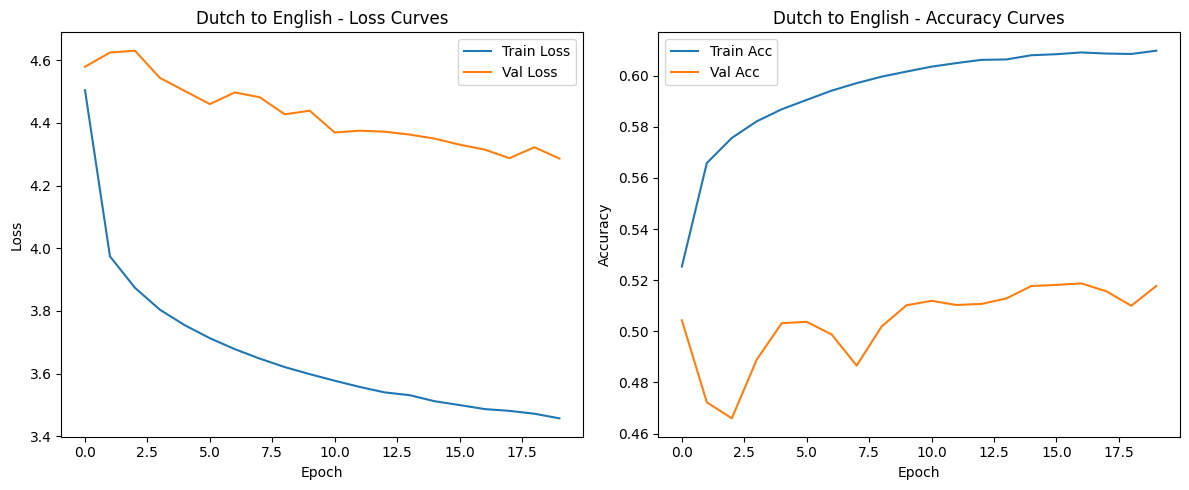

Final Validation BLEU (Dutch→English): 0.0477
Dutch to English training completed!
Results saved to: task3/nl_to_eng_results.pkl
Best model saved to: best_model_nl_to_eng.pt


In [3]:
# Plot results
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Dutch to English - Loss Curves')

plt.subplot(1,2,2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Dutch to English - Accuracy Curves')

plt.tight_layout()
plt.savefig('dutch_to_english_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Compute BLEU score
val_bleu = compute_bleu(model, val_loader, eng_vocab)
print(f"Final Validation BLEU (Dutch→English): {val_bleu:.4f}")

# Save results for comparison
nl_to_eng_results = {
    'direction': 'Dutch_to_English',
    'final_val_loss': val_losses[-1],
    'final_val_acc': val_accs[-1],
    'final_val_bleu': val_bleu,
    'train_losses': train_losses,
    'val_losses': val_losses,
    'train_accs': train_accs,
    'val_accs': val_accs,
    'vocab_sizes': {'source': len(nl_vocab), 'target': len(eng_vocab)}
}

import pickle
with open('nl_to_eng_results.pkl', 'wb') as f:
    pickle.dump(nl_to_eng_results, f)

print("Dutch to English training completed!")
print(f"Results saved to: task3/nl_to_eng_results.pkl")
print(f"Best model saved to: best_model_nl_to_eng.pt")